# TCN-Attention-LSTM模型(贝叶斯参数优化)+早停
1 导入数据  
2 数据归一化  
3 构造时间序列  
4 DataLoader  
5 定义模型结构  
6 定义训练函数  
7 贝叶斯优化搜索最优超参数  
8 用最优参数重新训练模型  
9 MC Dropout预测  
10 模型评估  



In [ ]:
#1.导入库  
#2.读取数据
#3.数据归一化  
#4.构造时间序列样本  
#5.转换为 PyTorch Tensor 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler   # 数据归一化
from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error, 
                             mean_absolute_percentage_error,
                             r2_score)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# from Model_evaluation import evaluate_model1, plot_prediction
# import NNmodel
# import optuna
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 读取数据
train = pd.read_csv("../data/dataset_selected_features_train.csv")
test = pd.read_csv("../data/dataset_selected_features_test.csv")

timestamp_test = pd.to_datetime(test["timestamp"])  # 转换时间格式
train = train.drop(columns=["timestamp"])
test = test.drop(columns=["timestamp"])
train = train.dropna()  # 删除lag产生的缺失值
test = test.dropna()  # 删除lag产生的缺失值

X_train = train.drop(columns=["load_kw"])
y_train = train["load_kw"]

X_test = test.drop(columns=["load_kw"])
y_test = test["load_kw"]

# 数据归一化
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)#.fit_transform是先拟合数据（计算出数据的最小值和最大值），然后进行转换（将数据缩放到指定范围）。在这里，X_train_scaled是经过归一化处理后的训练特征数据。
X_test_scaled = scaler_X.transform(X_test)#.transform是使用之前拟合好的scaler_X来转换测试特征数据X_test，确保测试数据使用与训练数据相同的缩放参数进行归一化处理。

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1))

#设定窗口大小为24，表示使用前24个时间步的数据来预测下一个时间步的负荷值。
TIME_STEPS = 96
def create_sequences(X, y, time_steps=TIME_STEPS):
    '''定义一个函数来创建输入序列和对应的预测目标，window参数指定了每个输入序列的长度。'''
    Xs = [] # 创建一个空列表来存储输入序列
    ys = [] # 创建一个空列表来存储预测目标
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])  # 将当前窗口内的数据作为输入序列
        ys.append(y[i+time_steps])  # 将窗口后的第一个数据点作为预测目标
    return np.array(Xs), np.array(ys)

Xs_train, ys_train = create_sequences(X_train_scaled,y_train_scaled,TIME_STEPS)
Xs_test, ys_test = create_sequences(X_test_scaled,y_test_scaled,TIME_STEPS)
print(Xs_train.shape) # 输出输入序列的形状，应该是(样本数量, 窗口大小, 特征数量)

Xs_train_tensor = torch.tensor(Xs_train,dtype=torch.float32)
ys_train_tensor = torch.tensor(ys_train,dtype=torch.float32)

Xs_test_tensor = torch.tensor(Xs_test,dtype=torch.float32)
ys_test_tensor = torch.tensor(ys_test,dtype=torch.float32)


(4129, 96, 6)


6.建立TCN-Attention-LSTM模型  
贝叶斯寻优+早停模块

In [17]:
#TCN部分 代码实现了一个TCNBlock类，表示一个TCN（Temporal Convolutional Network）块。这个块包含一个卷积层、一个ReLU激活函数和一个残差连接。卷积层使用因果填充（causal padding），确保输出的时间步只依赖于当前和之前的输入，而不依赖于未来的输入。在前向传播过程中，输入首先经过卷积层，然后裁剪掉因果卷积多出的padding，最后通过ReLU激活函数，并与残差连接的结果相加，得到最终的输出。
class TCNBlock(nn.Module):
    ''' TCN块：包含一个卷积层、一个ReLU激活函数和一个残差连接。卷积层使用因果填充，确保输出的时间步只依赖于当前和之前的输入，而不依赖于未来的输入。
    在前向传播过程中，输入首先经过卷积层，然后裁剪掉因果卷积多出的padding，最后通过ReLU激活函数，并与残差连接的结果相加，得到最终的输出。 '''
    def __init__(self, in_channels, out_channels, kernel_size, dilation,dropout=0.2):
        super(TCNBlock, self).__init__()
        self.padding = (kernel_size - 1) * dilation
        # 使用因果填充 (padding = (kernel_size-1)*dilation)
        self.conv = nn.Conv1d(in_channels, 
                              out_channels, 
                              kernel_size, 
                              padding=self.padding, 
                              dilation=dilation)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()        
        self.residual = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()# 残差连接
                #residual连接的作用是将输入直接添加到卷积层的输出中，以帮助缓解深层网络中的梯度消失问题。当输入和输出通道数不匹配时，使用一个1x1卷积来调整输入的维度，使其与输出维度一致；否则，使用恒等映射（Identity）直接传递输入。
    def forward(self, x):
        # x: [batch, channels, seq_len]
        out = self.conv(x)
        out = out[:, :, :-(self.conv.padding[0])] # 裁剪掉因果卷积多出的 padding
        out = self.relu(out)
        out = self.dropout(out)
        # 输入与输出相加实现残差
        return out + self.residual(x)

class SimpleAttention(nn.Module):
    '''定义了一个简单的注意力机制类SimpleAttention。这个类包含一个可训练的参数attn_weights，
    用于计算输入序列中每个时间步的注意力权重。在前向传播过程中，输入x首先通过矩阵乘法与attn_weights相乘，
    得到每个时间步的得分（scores）。然后，使用softmax函数对得分进行归一化，得到注意力权重（weights）。
    最后，将输入x与注意力权重相乘，得到加权输出。这种机制允许模型在处理序列数据时动态地关注不同时间步的重要性，从而提高模型的性能。
    '''
    def __init__(self, hidden_dim):
        super(SimpleAttention, self).__init__()
        self.attn_weights = nn.Parameter(torch.randn(hidden_dim, 1))

    def forward(self, x):
        # x: [batch, seq_len, hidden_dim]
        # 计算每个时间步的得分
        scores = torch.matmul(x, self.attn_weights).squeeze(-1) # [batch, seq_len]
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)   # 归一化
        return x * weights # 加权输出

class HybridModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(HybridModel, self).__init__()
        # 1. 增强型 TCN：增加扩张因子以覆盖 96 的感受野  1. TCN 部分 (提取空间/时间特征)
        tcn_layers = []
        channels = [input_size, 64, 64, 64, 64, 64 ]
        dilations = [1, 2, 4, 8, 16] # 感受野计算: 1+(2*1)+(2*2)+(2*4) = 15, 若要到96需更多层
        for i in range(len(dilations)):
            tcn_layers.append(
                TCNBlock(
                    channels[i], 
                    channels[i+1], 
                    kernel_size=3, 
                    dilation=dilations[i]
                    )   
                )        
        self.tcn = nn.Sequential(*tcn_layers)
            
        # 2. Attention 部分
        self.attention = SimpleAttention(64)
        
        # 3. LSTM 部分
        self.lstm = nn.LSTM(64, hidden_size, batch_first=True,num_layers=1, dropout=0.1)
        
        # 4. 输出层
        self.fc = nn.Linear(hidden_size + input_size, output_size)

    def forward(self, x):
        # 转换输入维度符合 Conv1d: [batch, features, seq_len]
        # 1. 保留原始输入的最后一个时间步特征 (即当前最实时的信息)
        raw_last_step = x[:, -1, :] # [batch, input_size]
        # 2. TCN 提取特征
        x = x.transpose(1, 2)
        x = self.tcn(x)          # 转换回 LSTM 维度: [batch, seq_len, features]  
        
        x = x.transpose(1, 2)
        # 经过 Attention 和 LSTM
        x = self.attention(x)
        _, (hn, _) = self.lstm(x) # 取最后一个状态   
        
        lstm_out = hn[-1] # [batch, hidden_size]
        
        # 3. 【全局跳跃连接】拼接深度特征和原始特征
        # 这步能强迫模型在预测时“参考”前一时刻的具体数值
        combined = torch.cat([lstm_out, raw_last_step], dim=1)

        return torch.relu(self.fc(combined)) 

class EarlyStopping:
    def __init__(self, patience=10, verbose=False, delta=0, path='best_model.pth'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

def train_model(model, train_loader, val_loader, epochs, lr ,
                patience=10, save_path='贝叶斯优化_TCN-Attention-LSTM-best_model.pth'):
    ''' 定义一个函数train_model，用于训练模型。这个函数接受模型、训练数据加载器、训练轮数和学习率作为输入。
    在函数内部，我们首先定义了损失函数（均方误差）和优化器（Adam）。
    然后，我们进入训练循环，在每个epoch中迭代训练数据加载器，进行前向传播、计算损失、反向传播和参数更新。
    最后，返回每个epoch的平均损失值，以供后续分析和调优使用。'''

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # 初始化早停
    early_stopping = EarlyStopping(patience=patience, verbose=False, path=save_path)
    loss_history = [] #train_losses
    val_losses = []
    
    for epoch in range(epochs):
        #训练阶段
        model.train()
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(DEVICE) # 将输入数据移动到指定的设备（GPU或CPU）上，以加速计算。
            batch_y = batch_y.to(DEVICE)
            # 梯度清零
            optimizer.zero_grad()
            # 前向传播
            outputs = model(batch_X)

            loss = criterion(outputs, batch_y)# 计算模型输出与真实标签之间的均方误差损失。

            loss.backward()# 反向传播，计算损失函数相对于模型参数的梯度。

            optimizer.step()# 更新模型参数，使用Adam优化器根据计算得到的梯度调整模型的权重。

            epoch_loss += loss.item()# 累积当前批次的损失值，以便在每个epoch结束时计算平均损失。
        
        avg_train_loss = epoch_loss / len(train_loader) # 计算当前epoch的平均损失值，通过将累积的损失值除以训练数据加载器中的批次数量来得到。
        
        # --- 验证阶段，带早停 ---
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                total_val_loss += loss.item()
        avg_val_loss = total_val_loss / len(val_loader)
        loss_history.append(avg_train_loss)    # 将每个epoch的平均损失值添加到train_losses列表中，以便后续分析和可视化训练过程中的损失变化。
        val_losses.append(avg_val_loss)

        # 检查早停逻辑
        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            break
    
    # 训练结束，加载本次训练中表现最好的模型权重
    model.load_state_dict(torch.load(save_path))

    return loss_history, val_losses

def objective(trial):
    ''' 定义一个目标函数objective，用于Optuna的超参数优化。这个函数接受一个trial对象作为输入，允许我们在其中定义要优化的超参数空间。
    在这个函数中，使用trial.suggest_int、trial.suggest_float和trial.suggest_categorical等方法来定义不同类型的超参数（如整数、浮点数和分类变量）。    
    然后，我们根据这些超参数重新创建数据加载器和模型，并调用train_model函数进行训练。
    最后，返回训练损失作为优化的目标，以便Optuna能够根据这个损失值来评估不同超参数组合的性能。'''
    
    hidden_size = trial.suggest_int("hidden_size", 32, 128) # 定义一个整数类型的超参数hidden_size，范围从32到128。Optuna将在这个范围内搜索最佳的hidden_size值，以优化模型的性能。

    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)# 定义一个浮点数类型的超参数lr，范围从1e-5到1e-2，并且使用对数尺度进行搜索。这意味着Optuna将在这个范围内以对数方式搜索最佳的学习率值，以优化模型的性能。

    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])# 定义一个分类变量类型的超参数batch_size，取值可以是32、64或128。Optuna将在这些选项中搜索最佳的batch_size值，以优化模型的性能。

    # 重新创建 DataLoader
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )
    validate_loader = DataLoader(
        validate_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    model = HybridModel(
        input_size=input_dim,
        hidden_size=hidden_size,
        output_size=1
    ).to(DEVICE)

    _, val_history = train_model(
        model, 
        train_loader, 
        validate_loader,
        epochs=100,# 训练轮数固定为20，以便快速评估不同超参数组合的性能。你可以根据需要调整这个值。
        lr=lr,
        patience=7, 
        save_path=f"../best_pth/temp_trial_{trial.number}.pth" # 每个trial保存一个临时模型权重文件，以便在训练过程中进行早停检查和最终加载最佳模型权重。
        )
    
    return min(val_history)


In [18]:
import torch, optuna
print(torch.__version__)
print(optuna.__version__)

2.5.1+cu121
4.8.0


6.初始化与训练  
贝叶斯优化部分需要写成函数

In [19]:
from torch.utils.data import DataLoader, TensorDataset
# --- 参数设置 ---
LEARNING_RATE = 0.001
BATCH_SIZE = 64
EPOCHS = 200
print(f"开始在 {DEVICE} 上训练...")
# --- 数据准备 ---
train_dataset = TensorDataset(Xs_train_tensor,ys_train_tensor)
validate_dataset = TensorDataset(Xs_test_tensor,ys_test_tensor)
# --- 初始化模型、损失函数与优化器 ---
input_dim = Xs_train_tensor.shape[2] #torch.Size([4129, 96, 17]),Xs_train_tensor.shape[2]是17，即特征数量。
# --- 贝叶斯优化 ---
study = optuna.create_study(direction="minimize")
print("input_dim", input_dim)
study.optimize(objective, n_trials=25)
best_params = study.best_params
print("最优参数：", best_params)

# 2. 正式训练准备
# 建议在正式训练时，依然划分一个小的验证集来触发早停
full_train_size = int(0.9 * len(train_dataset))
final_val_size = len(train_dataset) - full_train_size
f_t_data, f_v_data = torch.utils.data.random_split(train_dataset, [full_train_size, final_val_size])

final_train_loader = DataLoader(f_t_data, batch_size=best_params["batch_size"], shuffle=True)
final_val_loader = DataLoader(f_v_data, batch_size=best_params["batch_size"])

#--- 数据加载器
train_loader = DataLoader(
    train_dataset,
    batch_size=best_params["batch_size"],
    shuffle=True
)
# 3. 实例化最优模型并训练
model = HybridModel(
    input_size=input_dim,
    hidden_size=best_params["hidden_size"],
    output_size=1
).to(DEVICE)

'''train_losses = train_model(
    best_model,
    train_loader,
    epochs=EPOCHS,
    lr=best_params["lr"]
    )'''
train_losses, val_logs = train_model(
    model, 
    final_train_loader, 
    final_val_loader, 
    epochs=200, # 最终训练给足 Epoch
    lr=best_params["lr"],
    patience=15, # 耐心值可以设大一点
    save_path='../best_pth/final_best_hybrid_model.pth'
)


[I 2026-04-10 10:23:28,970] A new study created in memory with name: no-name-af708869-6833-48e0-b1f9-ceeb126910cf


开始在 cuda 上训练...
input_dim 6


C:\Users\25211\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(
C:\Users\25211\AppData\Local\Temp\ipykernel_27004\2717304949.py:178: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless 

最优参数： {'hidden_size': 69, 'lr': 0.0006238221652559504, 'batch_size': 128}


[0.04052755367010832, 0.019933908060193063, 0.017132822214625774, 0.015112966997548938, 0.0148467141824464, 0.013524857473870118, 0.015684389416128396, 0.014206740073859692, 0.012231088957438867, 0.011916282990326484, 0.011751258109385768, 0.011530202797924478, 0.011282367922831327, 0.011480712238699198, 0.01082330234736825, 0.012511868681758642, 0.010809740280577292, 0.010366689840642115, 0.01025724085047841, 0.009434710838831961, 0.00785790522932075, 0.00785403378928701, 0.007773682614788413, 0.007379041363795598, 0.007412899595995744, 0.007220237003639341, 0.0071286660308639204, 0.007287290180101991, 0.006984753456587593, 0.006576479234111806, 0.0066015877683336536, 0.006692606179664533, 0.006272443554674586, 0.00621690039212505, 0.00681963847600855, 0.006706649879924953, 0.005973230861127376, 0.005879025704537829, 0.006819395589021345, 0.011188637207184608, 0.00828618424323698, 0.007091752936442693, 0.007023637493451436, 0.006893063647051652, 0.006098950514569879, 0.006670421936238

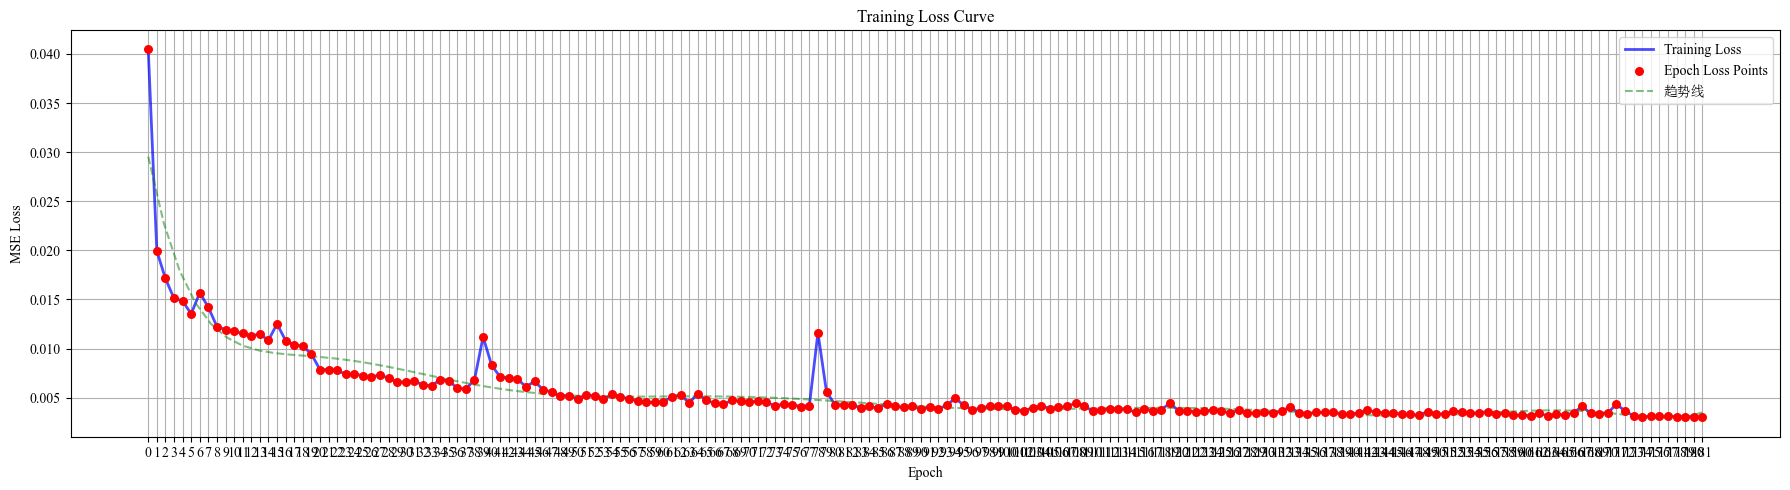

In [20]:
#---画损失曲线----
print(train_losses)

x = range(len(train_losses))
z = np.polyfit(x, train_losses, 10)  # 3次多项式拟合
p = np.poly1d(z)
x_smooth = np.linspace(0, len(train_losses)-1, 100)

plt.figure(figsize=(18,5))
plt.plot(train_losses, 'b-',linewidth=2, alpha=0.7, label="Training Loss")
plt.scatter(x, train_losses, color='red', 
            s=30, zorder=5, label="Epoch Loss Points")
plt.plot(x_smooth, p(x_smooth), 'g--', alpha=0.5, linewidth=1.5, label='趋势线')
plt.xticks(x) 
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

>训练集预测、查看拟合能力


训练集评价结果:
MAE  : 137.23 kW
RMSE : 179.04 kW
MAPE : 56.13%
R²   : 94.08%


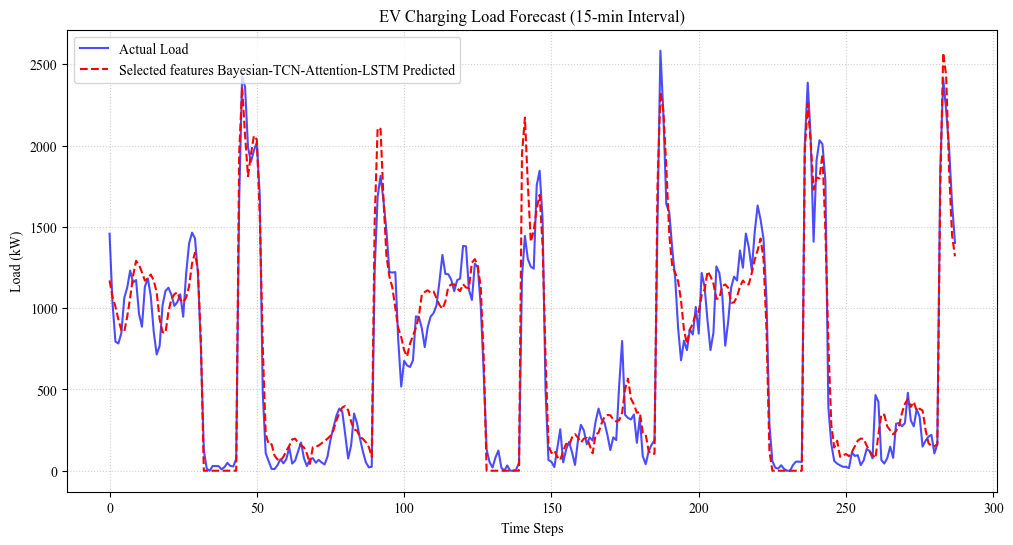

In [29]:
model.eval()

# ===== 训练集预测 =====
with torch.no_grad():# 在评估模式下禁用梯度计算，以节省内存和加速计算。
    train_pred = model(Xs_train_tensor.to(DEVICE)).cpu().numpy()

# --- 逆归一化 ---
y_train_real = scaler_y.inverse_transform(ys_train_tensor.cpu().numpy().reshape(-1,1))
y_train_pred = scaler_y.inverse_transform(train_pred.reshape(-1,1))

train_mae = mean_absolute_error(y_train_real, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_real, y_train_pred))
mask = y_train_real > 1
train_mape = np.mean(np.abs((y_train_real[mask] - y_train_pred[mask]) / y_train_real[mask]))
#train_mape = np.mean(np.abs((y_train_real - y_train_pred) / (y_train_real + 1e-5)))
train_r2 = r2_score(y_train_real, y_train_pred)

print("\n训练集评价结果:")
print(f"MAE  : {train_mae:.2f} kW")
print(f"RMSE : {train_rmse:.2f} kW")
print(f"MAPE : {train_mape:.2%}")
print(f"R²   : {train_r2:.2%}")
# --- 结果可视化 ---
# 选取测试集中前 4 天的数据进行展示 (96 * 4)
first_day = 0 
last_day = first_day + 96 * 3
plt.figure(figsize=(12, 6))
plt.plot(y_train_real[first_day:last_day], label='Actual Load', color='blue', alpha=0.7)
plt.plot(y_train_pred[first_day:last_day], label='Selected features Bayesian-TCN-Attention-LSTM Predicted', color='red', linestyle='--')
plt.title('EV Charging Load Forecast (15-min Interval)')
plt.xlabel('Time Steps')
plt.ylabel('Load (kW)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
#print(y_train_real[:10])
#print(y_train_pred[:10])

蒙特卡洛MC Dropout预测  
逆归一化

In [22]:
MC_TIMES=100
def predict_with_uncertainty(model, Xs_test_tensor, MC_TIMES=MC_TIMES):
    model.train() # 关键：保持 Dropout 开启
    predictions = []    
    with torch.no_grad():
        for _ in range(MC_TIMES):
            y_p = model(Xs_test_tensor)
            predictions.append(y_p.cpu().numpy())
            
    predictions = np.array(predictions) # 形状: [100, 样本数, 1]
    
    # 计算均值和标准差
    y_mean = predictions.mean(axis=0) # 均值：[样本数, 1]
    y_std = predictions.std(axis=0)   # 标准差：[样本数, 1]
    
    return y_mean, y_std

# 2. 执行 MC 采样预测 (替换原有的单次预测)
print("正在执行蒙特卡洛采样预测...")
y_pred_scaled, y_std_scaled = predict_with_uncertainty(model, Xs_test_tensor.to(DEVICE), MC_TIMES)


正在执行蒙特卡洛采样预测...


逆归一化

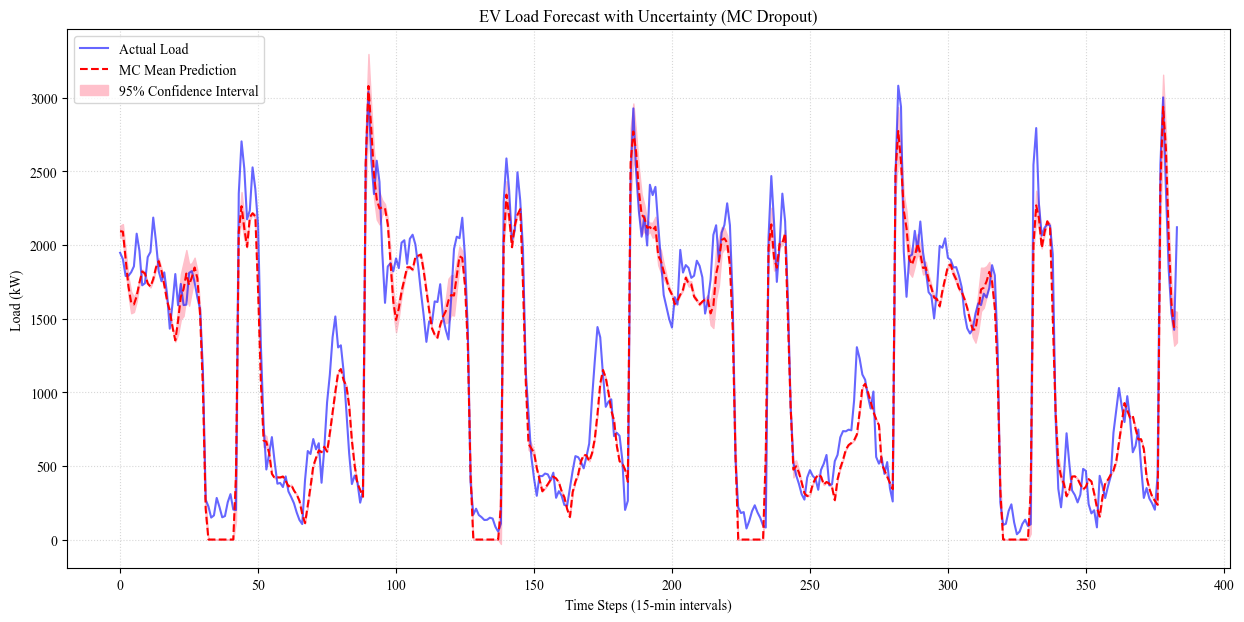

In [23]:
model.eval()# 将模型设置为评估模式，这会影响某些层的行为（如Dropout和BatchNorm），确保在评估阶段模型的行为与训练阶段不同。

#with torch.no_grad():# 在评估阶段，我们不需要计算梯度，因此使用torch.no_grad()上下文管理器来禁用梯度计算，以节省内存和提高计算效率。
# 对全部测试集进行预测
    #y_pred_scaled = model(Xs_test_tensor.to(DEVICE)).cpu().numpy()

# --- 逆归一化 ---
# 将 y_test 也准备好进行逆归一化（注意：y_test_lstm 已经是切片后的）
y_pred_real = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(ys_test.reshape(-1, 1))

# 标准差的逆归一化 (注意：标准差是区间宽度，只需乘以缩放系数，不需要加位移)
# 缩放系数 = max - min
scale_factor = scaler_y.data_max_[0] - scaler_y.data_min_[0]
y_std_real = y_std_scaled * scale_factor


# --- 结果可视化 ---
plt.figure(figsize=(15, 7))
# 选取展示范围
show_len = 384 
time_axis = range(show_len)
# 绘制实际值
plt.plot(time_axis, y_test_real[:show_len], label='Actual Load', color='blue', alpha=0.6)
# 绘制 MC 均值预测值
plt.plot(time_axis, y_pred_real[:show_len], label='MC Mean Prediction', color='red', linestyle='--')
# 绘制 95% 置信区间 (均值 ± 1.96 * 标准差)
lower_bound = (y_pred_real - 1.96 * y_std_real).flatten()[:show_len]
upper_bound = (y_pred_real + 1.96 * y_std_real).flatten()[:show_len]

plt.fill_between(time_axis, lower_bound, upper_bound, color='pink', alpha=1.0, label='95% Confidence Interval')
#alpha参数控制填充颜色的透明度，值越小越透明，这里设置为0.6，使得置信区间的填充颜色不会过于浓重，能够更好地与实际值和预测值的线条区分开来。
plt.title('EV Load Forecast with Uncertainty (MC Dropout)')
plt.xlabel('Time Steps (15-min intervals)')
plt.ylabel('Load (kW)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

10模型评价+预测结果图


预测评价结果:
MAE  : 179.76 kW
RMSE : 249.06 kW
MAPE : 14787732.08%
R²   : 90.59%


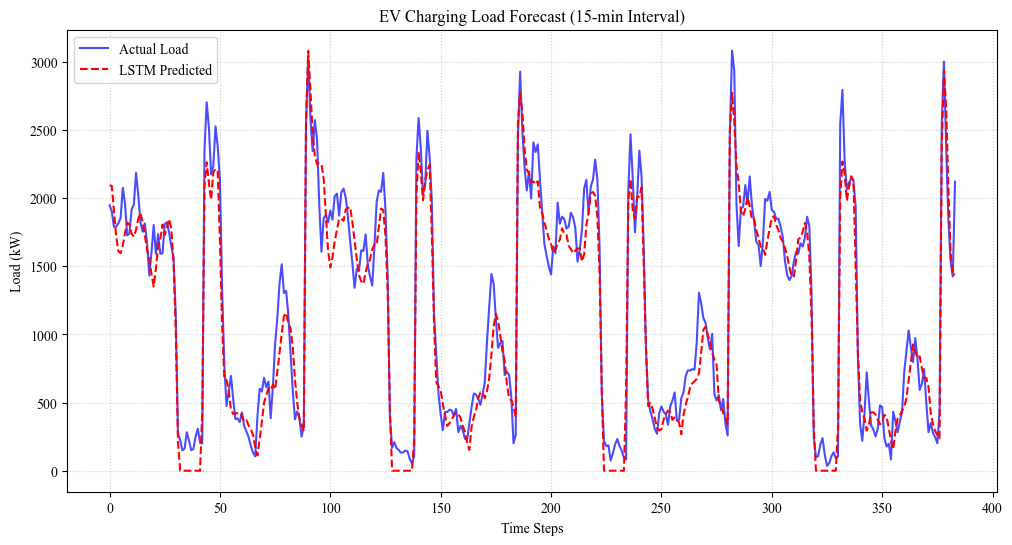

In [24]:
# --- 计算交通/能源领域常用指标 ---
mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
#mape = mean_absolute_percentage_error(y_test_real, y_pred_real)
mape = np.mean(np.abs((y_test_real - y_pred_real) / (y_test_real + 1e-5)))
r2 = r2_score(y_test_real, y_pred_real)
print("\n" + "="*30)
print(f"预测评价结果:")
print(f"MAE  : {mae:.2f} kW")
print(f"RMSE : {rmse:.2f} kW")
print(f"MAPE : {mape:.2%}")
print(f"R²   : {r2:.2%}")
print("="*30)
# --- 结果可视化 ---
# 选取测试集中前 4 天的数据进行展示 (96 * 4)
plt.figure(figsize=(12, 6))
plt.plot(y_test_real[:384], label='Actual Load', color='blue', alpha=0.7)
plt.plot(y_pred_real[:384], label='LSTM Predicted', color='red', linestyle='--')
plt.title('EV Charging Load Forecast (15-min Interval)')
plt.xlabel('Time Steps')
plt.ylabel('Load (kW)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


CNN-LSTM 评估结果：
MAE : 179.758
RMSE: 249.062
MAPE: 147874407.597 %
R2  : 0.906

CNN-LSTM预测曲线图如下：


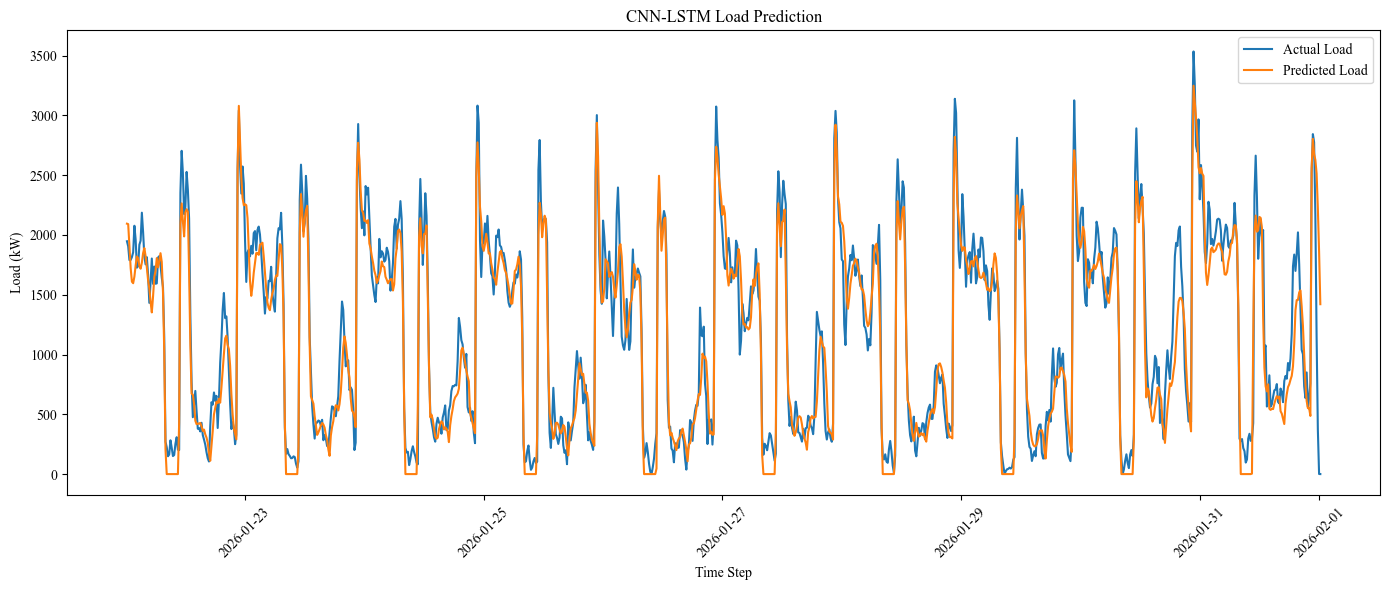

In [ ]:
torch.save(model.state_dict(), "tcn_attention_lstm.pth")


十三、预测结果图

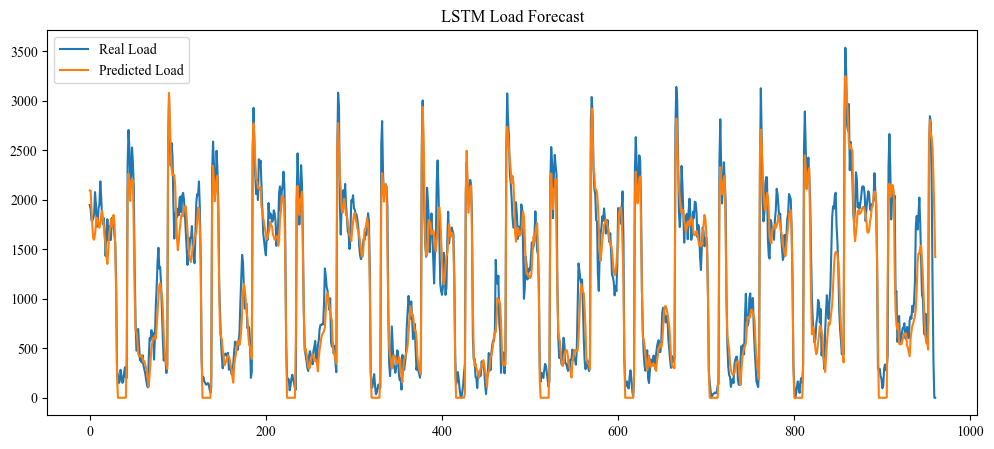

In [26]:
plt.figure(figsize=(12,5))
plt.plot(y_test_real, label="Real Load")
plt.plot(y_pred_real, label="Predicted Load")
plt.legend()
plt.title("LSTM Load Forecast")
plt.show()

In [27]:
print(test.columns)

Index(['price', 'lag_1', 'lag_96', 'lag_672', 'rolling_std_4',
       'rolling_mean_4', 'load_kw'],
      dtype='object')


十四、某一天预测效果

Selected day for detailed plot: 2026-01-31


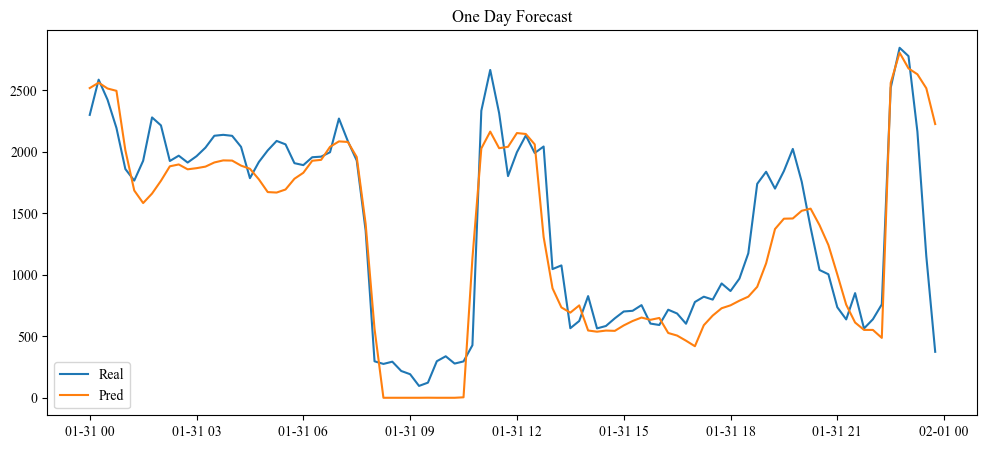

In [28]:

ONEDAY=9    #测试集一到七天的负荷曲线细节展示，取1-9
time_test = timestamp_test.iloc[-len(y_test_real):]#len(y_test_real) 获取测试集的长度，iloc[-len(y_test_real):] 从DataFrame的末尾开始，获取与测试集长度相同的时间戳数据。这样，我们就得到了与测试集对应的时间戳，可以用于后续的结果分析和可视化。
result = pd.DataFrame({
    "time":time_test.values,
    "real":y_test_real.flatten(),
    "pred":y_pred_real.flatten()
})
result["date"] = pd.to_datetime(result["time"]).dt.date

one_day = result["date"].iloc[ONEDAY*96]     #iloc[1] 获取第一行的日期，作为示例展示一天的负荷曲线细节。你可以修改为其他日期查看不同天的负荷曲线。

print("Selected day for detailed plot:", one_day)
day_data = result[result["date"]==one_day]
plt.figure(figsize=(12,5))
plt.plot(day_data["time"], day_data["real"], label="Real")
plt.plot(day_data["time"], day_data["pred"], label="Pred")
plt.legend()
plt.title("One Day Forecast")
plt.show()